# Experiment Comparison: 10000-10004
Comparing DQN, REINFORCE, CMA, ODT, and RWA on reduced experiment settings.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# -- Configuration --
# Set this to the base directory where metrics are saved.
# The script expects CSV files at: {METRICS_BASE}/Exp_{exp_num}/train/metrics_agent_episode_level.csv
# If you ran with: python main.py -e 10000 -d "/some/path/metrics/Exp"
# then METRICS_BASE should be "/some/path/metrics"
METRICS_BASE = "/storage_1/metrics"

EXPERIMENTS = {
    # 10000: "DQN",
    10005: "REINFORCE",
    10006: "RWA",
}

In [2]:
# Load agent metrics for each experiment
agent_data = {}
for exp_num, algo_name in EXPERIMENTS.items():
    csv_path = os.path.join(METRICS_BASE, f"Exp_{exp_num}", "train", "metrics_agent_episode_level.csv")
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        agent_data[algo_name] = df
        print(f"Loaded {algo_name} (Exp {exp_num}): {len(df)} rows")
    else:
        print(f"WARNING: {csv_path} not found — skipping {algo_name}")

Loaded REINFORCE (Exp 10005): 30302973 rows
Loaded RWA (Exp 10006): 28476513 rows


In [3]:
# Print average training time per experiment
# timestep_real_world_time is the wall-clock elapsed time recorded per episode
print("=" * 50)
print("Average Training Time")
print("=" * 50)
for algo_name, df in agent_data.items():
    # Get the max elapsed time per zone (each zone's timer runs independently)
    max_time_per_zone = df.groupby("zone")["timestep_real_world_time"].max()
    total_time = max_time_per_zone.mean()
    hours = int(total_time // 3600)
    minutes = int((total_time % 3600) // 60)
    seconds = int(total_time % 60)
    print(f"  {algo_name:>12s}: {hours:02d}h {minutes:02d}m {seconds:02d}s  ({total_time:.1f}s)")
print("=" * 50)

Average Training Time
     REINFORCE: 00h 00m 14s  (15.0s)
           RWA: 00h 00m 15s  (15.7s)


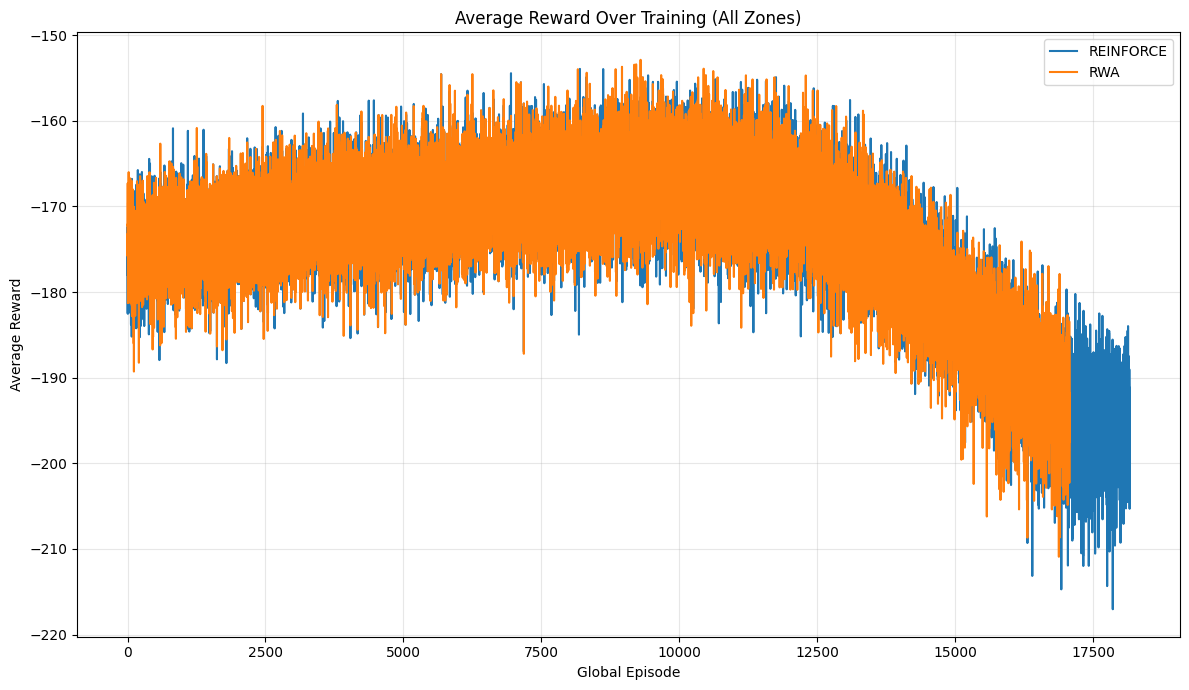

In [4]:
# Plot average reward over training (across all zones) for each algorithm
plt.figure(figsize=(12, 7))

for algo_name, df in agent_data.items():
    num_episodes = df.groupby("aggregation")["episode"].nunique().iloc[0]
    df = df.copy()
    df["global_episode"] = df["aggregation"] * num_episodes + df["episode"]

    # Average reward across all agents and zones per global episode
    avg_reward = df.groupby("global_episode")["reward"].mean()

    plt.plot(avg_reward.index, avg_reward.values, label=algo_name, linewidth=1.5)

plt.xlabel("Global Episode")
plt.ylabel("Average Reward")
plt.title("Average Reward Over Training (All Zones)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

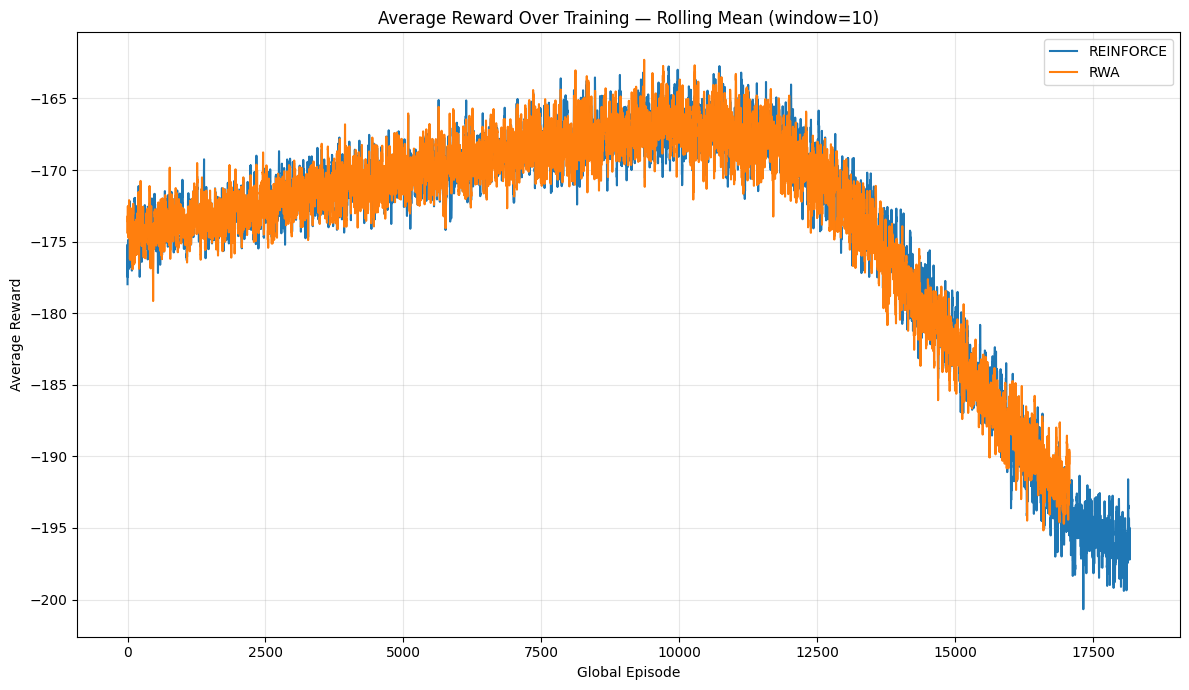

In [5]:
# Same plot but with a rolling average for smoother comparison
WINDOW = 10

plt.figure(figsize=(12, 7))

for algo_name, df in agent_data.items():
    num_episodes = df.groupby("aggregation")["episode"].nunique().iloc[0]
    df = df.copy()
    df["global_episode"] = df["aggregation"] * num_episodes + df["episode"]

    avg_reward = df.groupby("global_episode")["reward"].mean()
    smoothed = avg_reward.rolling(window=WINDOW, min_periods=1).mean()

    plt.plot(smoothed.index, smoothed.values, label=algo_name, linewidth=1.5)

plt.xlabel("Global Episode")
plt.ylabel("Average Reward")
plt.title(f"Average Reward Over Training — Rolling Mean (window={WINDOW})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

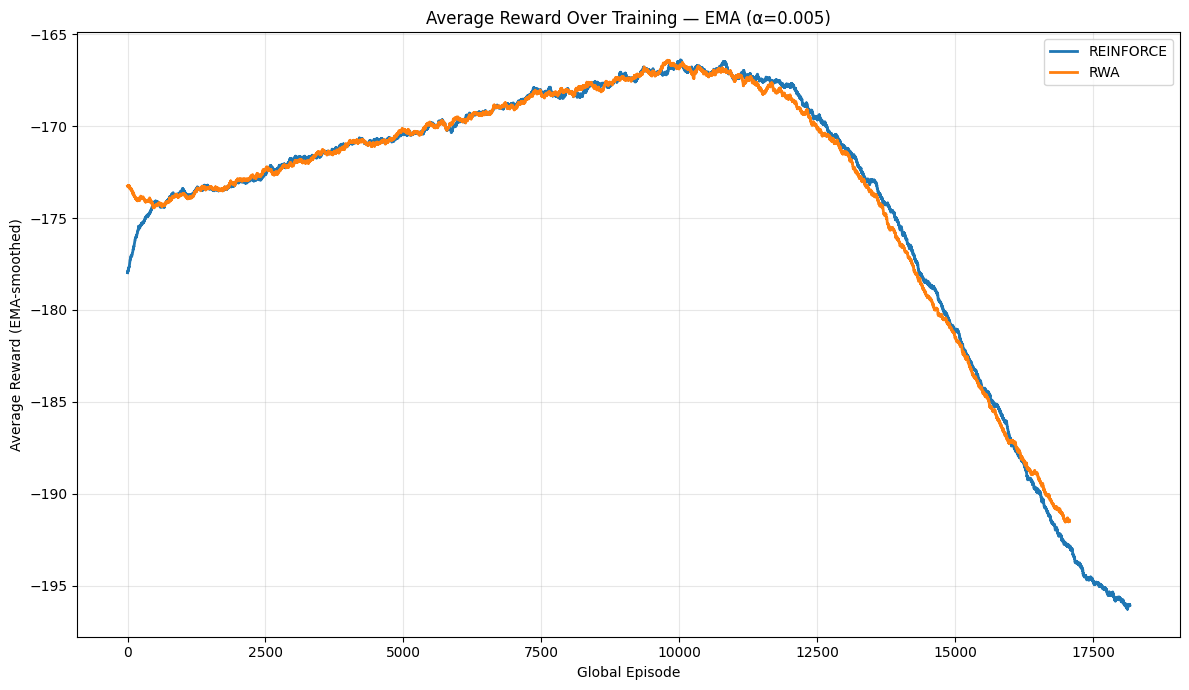

In [6]:
# Smoothed comparison using Exponential Moving Average (EMA)
# EMA responds faster to recent changes than a rolling mean and shows the overall trend clearly.
# Adjust ALPHA (0–1): smaller = smoother, larger = more responsive.
ALPHA = 0.005

plt.figure(figsize=(12, 7))

for algo_name, df in agent_data.items():
    num_episodes = df.groupby("aggregation")["episode"].nunique().iloc[0]
    df = df.copy()
    df["global_episode"] = df["aggregation"] * num_episodes + df["episode"]

    avg_reward = df.groupby("global_episode")["reward"].mean()
    smoothed = avg_reward.ewm(alpha=ALPHA, adjust=False).mean()

    plt.plot(smoothed.index, smoothed.values, label=algo_name, linewidth=2)

plt.xlabel("Global Episode")
plt.ylabel("Average Reward (EMA-smoothed)")
plt.title(f"Average Reward Over Training — EMA (α={ALPHA})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()